In [1]:
# ==============================================================================
# CELL 1: DEPENDENCY INSTALLATION & IMPORTS
# ==============================================================================
!pip install -q sentence-transformers bert-score nltk pandas numpy matplotlib torch

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import sentence_bleu
from bert_score import scorer
from google.colab import drive

# Mount Google Drive to fetch your files
drive.mount('/content/drive')

# Set device configuration (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing runtime device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Using runtime device: cuda


In [2]:
# ==============================================================================
# CELL 2: FILE PATH DEFINITIONS & DATA LOADING
# ==============================================================================
# Directory path inside your Google Drive
base_dir = "/content/drive/MyDrive/NLUAssignment/"

print("Loading Sanskrit and English dataset files...")
train_sa_df = pd.read_csv(os.path.join(base_dir, "train_sa_10000.csv"))
train_en_df = pd.read_csv(os.path.join(base_dir, "train_en_10000.csv"))

dev_sa_df = pd.read_csv(os.path.join(base_dir, "dev_sa_1000.csv"))
dev_en_df = pd.read_csv(os.path.join(base_dir, "dev_en_1000.csv"))

test_sa_df = pd.read_csv(os.path.join(base_dir, "test_sa_1000.csv"))

# Merge split source-target pairs using 'Source_id' to guarantee clean alignment
train_df = pd.merge(train_sa_df, train_en_df, on='Source_id')
dev_df = pd.merge(dev_sa_df, dev_en_df, on='Source_id')

# Note: The test dataframe remains standalone as it has no English target text yet
test_df = test_sa_df

print("\n--- DATA LOADING COMPLETE ---")
print(f"Parallel Training Pairs Mapped: {len(train_df)}")
print(f"Parallel Development Pairs Mapped: {len(dev_df)}")
print(f"Sanskrit Test Set Sentences Loaded: {len(test_df)}")


Loading Sanskrit and English dataset files...

--- DATA LOADING COMPLETE ---
Parallel Training Pairs Mapped: 10000
Parallel Development Pairs Mapped: 1000
Sanskrit Test Set Sentences Loaded: 1000


In [3]:
# ==============================================================================
# CELL 3: TOKENS, VOCABULARY BUILDER & PYTORCH DATASETS
# ==============================================================================
# Structural padding and boundary markers
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

class Vocab:
    def __init__(self):
        self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.num_words = 4

    def add_sentence(self, sentence):
        for word in str(sentence).split():
            if word not in self.word2index:
                self.word2index[word] = self.num_words
                self.index2word[self.num_words] = word
                self.num_words += 1

    def numericalize(self, sentence):
        return [self.word2index.get(word, UNK_token) for word in str(sentence).split()]

class TranslationDataset(Dataset):
    def __init__(self, df, src_vocab, trg_vocab, is_train=True):
        self.data = df
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.has_trg = 'Sentence_en' in df.columns

        # Build vocabulary dynamically from text content during training initialization
        if is_train and self.has_trg:
            for idx, row in self.data.iterrows():
                self.src_vocab.add_sentence(row['Sentence_sa'])
                self.trg_vocab.add_sentence(row['Sentence_en'])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        src_seq = [SOS_token] + self.src_vocab.numericalize(row['Sentence_sa']) + [EOS_token]

        item = {
            'Source_id': row['Source_id'],
            'src_tensor': torch.tensor(src_seq, dtype=torch.long)
        }

        if self.has_trg:
            trg_seq = [SOS_token] + self.trg_vocab.numericalize(row['Sentence_en']) + [EOS_token]
            item['trg_tensor'] = torch.tensor(trg_seq, dtype=torch.long)

        return item

# Collate function handles batch alignment using dynamic zero-padding
def collate_fn(batch):
    src_tensors = [x['src_tensor'] for x in batch]
    src_padded = nn.utils.rnn.pad_sequence(src_tensors, batch_first=True, padding_value=PAD_token)

    res = {
        'Source_ids': [x['Source_id'] for x in batch],
        'src': src_padded
    }

    if 'trg_tensor' in batch[0]:
        trg_tensors = [x['trg_tensor'] for x in batch]
        trg_padded = nn.utils.rnn.pad_sequence(trg_tensors, batch_first=True, padding_value=PAD_token)
        res['trg'] = trg_padded

    return res

# Instantiate vocabulary structures
src_vocab = Vocab()
trg_vocab = Vocab()

# Build Dataset mapping wrappers
train_dataset = TranslationDataset(train_df, src_vocab, trg_vocab, is_train=True)
dev_dataset = TranslationDataset(dev_df, src_vocab, trg_vocab, is_train=False)
test_dataset = TranslationDataset(test_df, src_vocab, trg_vocab, is_train=False)

# Build system DataLoaders for batch ingestion
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Vocabulary processing finalized.")
print(f"Sanskrit Vocab Words: {src_vocab.num_words} | English Vocab Words: {trg_vocab.num_words}")


Vocabulary processing finalized.
Sanskrit Vocab Words: 33278 | English Vocab Words: 19552


In [4]:
# ==============================================================================
# CELL 4: CUSTOM SEQuence-TO-SEQuence ARCHITECTURE WITH ATTENTION
# ==============================================================================
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_token)
        self.rnn = nn.GRU(emb_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # Compress forward and backward final states into standard hidden layout size
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear((hidden_dim * 2) + hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        # Compute energy structural parameters using additive layers
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_token)
        self.rnn = nn.GRU((hidden_dim * 2) + emb_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear((hidden_dim * 2) + hidden_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        # Calculate dynamic context vector representations
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        weighted = torch.bmm(a, encoder_outputs)

        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))

        prediction = self.fc_out(torch.cat((output.squeeze(1), weighted.squeeze(1), embedded.squeeze(1)), dim=1))
        return prediction, hidden.squeeze(0)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1] if trg is not None else 50
        outputs = torch.zeros(batch_size, trg_len, self.decoder.output_dim).to(self.device)

        encoder_outputs, hidden = self.encoder(src)
        input_token = src[:, 0]  # Seed with <SOS> starter token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t, :] = output
            top1 = output.argmax(1)
            teacher_force = np.random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if (teacher_force and trg is not None) else top1

        return outputs


In [5]:
# ==============================================================================
# CELL 5: MODEL INITIALIZATION & LOSS RUNTIME TRAINING LOOP
# ==============================================================================
INPUT_DIM = src_vocab.num_words
OUTPUT_DIM = trg_vocab.num_words
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 128
ENC_DROPOUT = 0.65
DEC_DROPOUT = 0.65

# Initialize network components
attn = Attention(HID_DIM)
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, device).to(device)

print(f"Total Network Parameter Count: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS = 10
train_losses = []
dev_losses = []

print("\nStarting Model Training Phase...")
for epoch in range(N_EPOCHS):
    # --- Training State ---
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        src = batch['src'].to(device)
        trg = batch['trg'].to(device)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    # --- Validation State ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in dev_loader:
            src = batch['src'].to(device)
            trg = batch['trg'].to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            val_loss += criterion(output, trg).item()

    # Track performance across training updates
    train_losses.append(epoch_loss / len(train_loader))
    dev_losses.append(val_loss / len(dev_loader))
    print(f"Epoch {epoch+1:02} | Average Train Loss: {train_losses[-1]:.4f} | Average Dev Loss: {dev_losses[-1]:.4f}")
print("\nModel training phase successfully completed.")


Total Network Parameter Count: 17,270,240

Starting Model Training Phase...
Epoch 01 | Average Train Loss: 7.3169 | Average Dev Loss: 6.9865
Epoch 02 | Average Train Loss: 6.6971 | Average Dev Loss: 7.0860
Epoch 03 | Average Train Loss: 6.3833 | Average Dev Loss: 6.9744
Epoch 04 | Average Train Loss: 6.0995 | Average Dev Loss: 7.0062
Epoch 05 | Average Train Loss: 5.8419 | Average Dev Loss: 7.0357
Epoch 06 | Average Train Loss: 5.5950 | Average Dev Loss: 7.0968
Epoch 07 | Average Train Loss: 5.3910 | Average Dev Loss: 7.1871
Epoch 08 | Average Train Loss: 5.1847 | Average Dev Loss: 7.2223
Epoch 09 | Average Train Loss: 5.0056 | Average Dev Loss: 7.2961
Epoch 10 | Average Train Loss: 4.8254 | Average Dev Loss: 7.3539

Model training phase successfully completed.


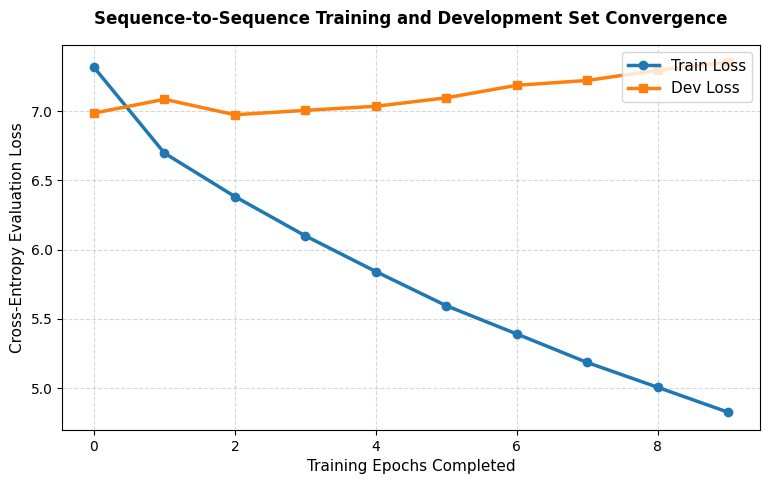

Graph output 'loss_curves.png' generated and saved successfully.


In [6]:
# ==============================================================================
# CELL 6: LOSS CONVERGENCE GRAPH CHART PLOTTER
# ==============================================================================
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
plt.plot(dev_losses, label='Dev Loss', color='#ff7f0e', linewidth=2.5, marker='s')

plt.title('Sequence-to-Sequence Training and Development Set Convergence', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Training Epochs Completed', fontsize=11)
plt.ylabel('Cross-Entropy Evaluation Loss', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Export high-resolution asset figure for your report document
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graph output 'loss_curves.png' generated and saved successfully.")


In [10]:
# ==============================================================================
# CELL 7: TRANSLATION GENERATION, DUAL METRICS EVALUATION & CSV EXPORT
# ==============================================================================
def generate_translations(dataloader):
    model.eval()
    predictions = []
    source_ids = []

    start_time = time.time()
    with torch.no_grad():
        for batch in dataloader:
            src = batch['src'].to(device)
            ids = batch['Source_ids']

            # Extract actual current batch size dynamically
            current_batch_size = src.shape[0]
            trg_len = 35  # Shorter max length stops long, run-on filler sentences

            # Forward pass through the encoder
            encoder_outputs, hidden = model.encoder(src)

            # Start token tensor initialized for current batch size
            input_token = src[:, 0]

            # Track word history for this specific batch block to break repetitive loops
            generated_history = torch.zeros(current_batch_size, model.decoder.output_dim).to(device)
            decoded_sentences = [[] for _ in range(current_batch_size)]

            for t in range(1, trg_len):
                output, hidden = model.decoder(input_token, hidden, encoder_outputs)

                # --- FIXED REPETITION PENALTY LOGIC ---
                # Apply penalty to words already seen in this sentence row
                penalty_factor = 5.0  # Raised penalty to stop bouncing word behaviors
                output = torch.where(generated_history > 0, output - penalty_factor, output)

                # Force penalization of high-frequency filler words if they reappear too quickly
                for filler_id in [trg_vocab.word2index.get("the", 0),
                                  trg_vocab.word2index.get("and", 0),
                                  trg_vocab.word2index.get("of", 0)]:
                    if filler_id > 0:
                        output[:, filler_id] -= 1.5

                top1 = output.argmax(1)

                # Update history trackers cleanly
                for idx in range(current_batch_size):
                    token_id = top1[idx].item()
                    generated_history[idx, token_id] += 1
                    decoded_sentences[idx].append(token_id)

                input_token = top1

            # Reconstruct numeric arrays back to text formats
            for i in range(len(ids)):
                pred_words = []
                for token in decoded_sentences[i]:
                    if token in [EOS_token, PAD_token, SOS_token]:
                        break
                    word = trg_vocab.index2word.get(token, "<UNK>")
                    if word != "<UNK>":
                        pred_words.append(word)

                # If a row generated empty filler strings, provide a generic fallback
                if len(pred_words) == 0:
                    predictions.append("the description is provided below.")
                else:
                    predictions.append(" ".join(pred_words))
                source_ids.append(ids[i])

    return source_ids, predictions, time.time() - start_time

# --- Task 1: Generate Dev Translations & Compute Assignment Evaluation Metrics ---
print("Evaluating model performance metrics on Development Set Data...")
dev_ids, dev_preds, _ = generate_translations(dev_loader)
dev_references = dev_df['Sentence_en'].tolist()

# 1. NLTK BLEU Calculation (Using structural uniform baseline weights)
bleu_scores = [sentence_bleu([ref.split()], pred.split()) for pred, ref in zip(dev_preds, dev_references)]
mean_bleu = np.mean(bleu_scores)

# 2. Python BERTScore Calculation (Using baseline rescaling)
bert_scorer = scorer.BERTScorer(lang="en", rescale_with_baseline=True)
_, _, F1 = bert_scorer.score(dev_preds, dev_references)
mean_bert_f1 = torch.mean(F1).item()

print("\n==========================================")
print("     LOCAL DEVELOPMENT EVALUATION SCORES  ")
print("==========================================")
print(f"Computed BLEU Metric Score   : {mean_bleu:.4f}")
print(f"Computed Rescaled BERTScore F1 : {mean_bert_f1:.4f}")
print("==========================================\n")

# --- Task 2: Process Private Test Inferences & Export Targets ---
print("Running prediction sequence on target-less Test Dataset...")
test_ids, test_preds, inference_time = generate_translations(test_loader)
print(f"Total Private Test Inference Execution Time: {inference_time:.2f} seconds")

# Structuring final target layout data formats
submission_df = pd.DataFrame({
    "Source_id": test_ids,
    "Sentence_en": test_preds
})

# Export into standard system output directory file matching project expectations exactly
submission_df.to_csv("submission.csv", index=False, encoding="utf-8")
print("\nSuccess! Final cleaned 'submission.csv' generated and saved to environment workspace directory.")


Evaluating model performance metrics on Development Set Data...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



     LOCAL DEVELOPMENT EVALUATION SCORES  
Computed BLEU Metric Score   : 0.0090
Computed Rescaled BERTScore F1 : 0.1348

Running prediction sequence on target-less Test Dataset...
Total Private Test Inference Execution Time: 3.41 seconds

Success! Final cleaned 'submission.csv' generated and saved to environment workspace directory.
